# Building a World Model with a Joint-Embedding Predictive Architecture (JEPA)

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Companion//main/jepa/jepa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [1]:
# !pip install deeplay  # Uncomment if using Colab/Kaggle.

A central hypothesis in self-supervised learning is that systems can build broad, general knowledge of the world largely from observation, without needing labels for everything they're meant to learn. Joint-Embedding Predictive Architectures (JEPAs) put this into practice by predicting the representation of one part of an input from another, rather than reconstructing the raw input itself.

In this notebook, you'll use a JEPA to build a small world model of a bouncing particle, a simplified but genuine testbed for self-supervised video representation learning. You'll see how training a predictor entirely in latent space — to predict the representation of future frames instead of the pixels themselves — lets a network learn where an object is and how fast it's moving without ever being given position or velocity labels, compare the model's predicted trajectory against the true simulated one, and investigate how far the network can roll a scene forward in time from just two seed frames.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This companion example extends several ideas introduced throughout the book, specifically, using convolutional networks to extract local image features (Chapter 3), self-supervised learning to train without labels (Chapter 6), attention and transformers to relate those features across space and time (Chapter 8), and learning to emulate the evolution of physical systems (Chapters 11 and 14).

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Understanding Joint-Embedding Predictive Architectures

Several theories in cognitive science propose that humans build an internal model of the world by integrating raw sensory input into a representation that predicts what will happen next, and that this internal model shapes perception itself, moment to moment. If an artificial agent could learn a world model the same way, directly from raw sensory data and without manual labels, it could understand its surroundings, anticipate what happens next, and plan for situations it has never encountered before.

Video is a good place to start: it captures how a scene evolves directly, frame by frame. A natural first attempt would be to train a network to predict future frames directly, pixel by pixel. Imagine watching a short clip of a ball rolling across a table: even without seeing what happens next, you can be fairly confident about where it will be a moment later and how fast it's moving. What you can't predict is much less important, the exact play of light on its surface, or a faint shadow shifting as the camera trembles slightly. Forcing a network to predict pixels forces it to get all of this right, including the parts that were never predictable in the first place. In practice, this backfires: since the network can't know how the unpredictable details will turn out, it hedges its bets and produces a blurry average over the possibilities, spending most of its capacity guessing at things that were never guessable, instead of learning the structure, like the ball's position and motion, that actually matters.

Joint-Embedding Predictive Architectures take a different, non-generative approach to the same problem: rather than predicting future pixels, they predict the future's internal representation, a compressed description that keeps only what's predictable and discards the rest. Because the network never has to reconstruct fine, unpredictable detail, it can dedicate its capacity to the underlying structure of the scene, which is exactly what lets a JEPA-trained network learn about an object's position, velocity, or identity without ever being told these are the things to look for.

### Defining the Problem

Consider an agent that only has access to a stream of raw observations (e.g., a video) of some dynamical system, with no information about the physical rules that govern it. The problem is to learn, directly from these observations and without any labels, a representation that captures the system's underlying state, such as the position and velocity of the objects it contains, and that can be used to predict how that state will evolve over time.

### Encoders, Predictors, and Training

A JEPA is built from three parts: two encoders and a predictor. It takes two inputs, $x$ and $y$, and passes each through an encoder to produce two representations, $s_x$ and $s_y$. $x$ is usually called the *context*, since it's what the model is given, and $y$ the *target*, since it's what has to be predicted. The same terms apply to their representations: $s_x$ is the context representation, $s_y$ is the target representation.

The two encoders don't need to share an architecture or parameters, which is what lets $x$ and $y$ come from entirely different signals or two different views of the same scene. A predictor module then learns to produce $s_y$ from $s_x$. Because $x$ doesn't always determine $y$ exactly, the predictor can also take a latent variable $z$ as input, letting it represent several plausible outcomes rather than being forced to commit to one.

Masking is one common way to create that split: by holding part of the input back from the context encoder, there's something genuinely left to predict, rather than reconstruct from something already fully visible. Holding out whole contiguous blocks, rather than scattering individually hidden patches, matters too: if the model could attend to a token right next to a hidden one, it could get away with simple local interpolation instead of learning how the scene actually evolves.

To prevent the model from collapsing to a trivial solution, such as mapping every input to the same constant representation, the target encoder is never trained directly. Instead, it's a slowly updated exponential moving average (EMA) of the context encoder, so the prediction target evolves gradually and stays consistent throughout training.

The predictor is trained by comparing its predicted representation to the target encoder's actual representation, using a simple distance in representation space rather than a pixel-wise loss.

## The Physical System

You'll apply these ideas to a small, concrete system: a single bead moving at constant velocity inside a square box, bouncing off the walls.

The first step is to define the ground-truth physics: a bead moves at a constant, randomly chosen integer-pixel velocity and bounces elastically off the image boundary, reversing whichever velocity component hit the wall.

In [2]:
import numpy as np

IMAGE_SIZE = 24
N_FRAMES = 20
DELTA_T = 1.0
MARGIN = 0

DISCRETE_VELOCITIES = np.array([
    [-1, -1], [-1, 0], [-1, 1],
    [ 0, -1],          [ 0, 1],
    [ 1, -1], [ 1, 0], [ 1, 1],
    [-2,  0], [ 2,  0], [ 0, -2], [ 0,  2],
    [-2, -1], [-2,  1], [ 2, -1], [ 2,  1],
    [-1, -2], [-1,  2], [ 1, -2], [ 1,  2],
], dtype=np.int32)

def random_discrete_velocity():
    return DISCRETE_VELOCITIES[np.random.randint(len(DISCRETE_VELOCITIES))].copy()

def reflect_grid(pos, vel, lower, upper):
    """Reflect one integer coordinate in the inclusive [lower, upper] range."""
    if pos < lower:
        return lower + (lower - pos), -vel
    if pos > upper:
        return upper - (pos - upper), -vel
    return pos, vel

def simulate_trajectory(radius,
                        image_size=IMAGE_SIZE, n_frames=N_FRAMES,
                        delta_t=DELTA_T, margin=MARGIN,
                        seed=None):
    """One fixed-shape bead moving on an integer pixel grid."""
    if seed is not None:
        np.random.seed(seed)
    
    radius_pixels = int(np.floor(radius))
    lower = margin + radius_pixels
    upper = image_size - margin - 1 - radius_pixels
    if lower >= upper:
        raise ValueError("Image is too small for this bead radius and margin.")

    pos = np.random.randint(lower, upper + 1, size=2, dtype=np.int32)
    vel = random_discrete_velocity()

    positions = [pos.copy()]
    velocities = [vel.copy()]
   
    for _ in range(n_frames - 1):
        pos = pos + vel

        pos[0], vel[0] = reflect_grid(pos[0], vel[0], lower, upper)
        pos[1], vel[1] = reflect_grid(pos[1], vel[1], lower, upper)

        positions.append(pos.copy())
        velocities.append(vel.copy())


    return (np.array(positions, dtype=np.float32),
            np.array(velocities, dtype=np.float32))

The next step is turning positions into pixels. `render_trajectories` draws the bead as a soft, radially-fading disc.

You'll also add distractors, small flickering rectangles appearing, disappearing, and relocating unpredictably from frame to frame. 

`make_clip` ties it together: one simulated trajectory, rendered both with and without distractors, alongside the ground-truth position and velocity.

In [ ]:
BEAD_RADIUS = 4.5
BEAD_INTENSITY = 0.7
DISTRACTOR_INTENSITY = 1.0

def render_trajectories(positions, radius=BEAD_RADIUS, image_size=IMAGE_SIZE,
                        intensity=BEAD_INTENSITY, sigma=None):
    """Render a video of a circular bead with a radial intensity falloff."""

    if sigma is None:
        sigma = radius / 2.0  # ~14% of peak intensity right at the edge
    yy, xx = np.meshgrid(np.arange(image_size), np.arange(image_size), indexing="ij")
    frames = np.zeros((len(positions), image_size, image_size), dtype=np.float32)
    for t, (row, col) in enumerate(positions):
        dist_sq = (yy - row) ** 2 + (xx - col) ** 2
        bead = dist_sq <= radius ** 2
        frames[t, bead] = intensity * np.exp(-dist_sq[bead] / (2 * sigma ** 2))
    return frames


def sample_distractor_rects(image_size=IMAGE_SIZE, n_min=1, n_max=3, side_min=1, side_max=4):
    """Sample a random number of small, static rectangular distractors."""

    n = np.random.randint(n_min, n_max + 1)
    rects = []
    for _ in range(n):
        h = np.random.randint(side_min, side_max + 1)
        w = np.random.randint(side_min, side_max + 1)
        row0 = np.random.randint(0, image_size - h + 1)
        col0 = np.random.randint(0, image_size - w + 1)
        rects.append((row0, col0, h, w))
    return rects

def add_flickering_distractors(frames, p_present=0.75, n_min=1, n_max=4,
                                side_min=1, side_max=3, intensity=DISTRACTOR_INTENSITY):
    """Stamp random rectangular distractors onto a random subset of frames."""

    out = frames.copy()
    T, H, W = frames.shape
    for t in range(T):
        if np.random.rand() > p_present:
            continue
        rects = sample_distractor_rects(image_size=H, n_min=n_min, n_max=n_max,
                                         side_min=side_min, side_max=side_max)
        for row0, col0, h, w in rects:
            out[t, row0:row0 + h, col0:col0 + w] = np.maximum(
                out[t, row0:row0 + h, col0:col0 + w], intensity
            )
    return out

def make_clip(radius=BEAD_RADIUS):
    """Simulate one trajectory and return matched views."""
    
    positions, vel = simulate_trajectory(radius)
    clean = render_trajectories(positions, radius)
    w_distractors = add_flickering_distractors(clean)
    return clean, w_distractors, positions, vel

A quick visual sanity check: this animates one clip side by side, clean and with distractors, along with the ground-truth velocity and speed at each frame.

In [4]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

clean_frames, w_distractors_frames, positions, vel = make_clip()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
im_clean = axes[0].imshow(clean_frames[0], cmap="gray", vmin=0, vmax=1)
im_w_distractors = axes[1].imshow(w_distractors_frames[0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clean view")
axes[1].set_title("With distractors view")
for ax in axes:
    ax.axis("off")

def update(i):
    im_clean.set_data(clean_frames[i])
    im_w_distractors.set_data(w_distractors_frames[i])
    row_velocity, col_velocity = vel[i]
    speed = np.linalg.norm(vel[i])
    fig.suptitle(
        f"Frame {i}   |   velocity = ({row_velocity:+.0f}, {col_velocity:+.0f})"
        f"   |   speed = {speed:.2f}   "
    )
    return [im_clean, im_w_distractors]

anim = animation.FuncAnimation(
    fig, update, frames=len(clean_frames), interval=150, blit=False
)
plt.close(fig)

HTML(anim.to_jshtml())

The following helper function ties everything together: simulate a trajectory, render both clean and distractor views, and repeat for as many clips as needed, saving the result to disk in one call.

In [5]:
import torch

def build_and_save_dataset(path, n_clips=5000, radius=BEAD_RADIUS):
    """Generate n_clips random trajectories, render both clean and distractor 
    views for each, and save everything to `path` as a single .pt file.
    """

    clean_clips, w_distractors_clips = [], []
    positions_list, velocities_list = [], []
    for _ in range(n_clips):
        clean, w_distractors, positions, vel = make_clip(radius)
        clean_clips.append(torch.from_numpy(clean).unsqueeze(0))
        w_distractors_clips.append(torch.from_numpy(w_distractors).unsqueeze(0))
        positions_list.append(torch.from_numpy(positions))
        velocities_list.append(torch.from_numpy(vel))

    clean_clips = torch.stack(clean_clips).float()
    torch.save({
        "clips_clean": clean_clips,
        "clips_w_distractors": torch.stack(w_distractors_clips).float(),
        "positions": torch.stack(positions_list).float(),
        "velocities": torch.stack(velocities_list).float(),
    }, path)
    print(f"saved {n_clips} clips to {path}")



With the function defined, generate the train, validation, and test splits. Each is saved to disk once, so re-running this notebook later loads the existing files instead of resimulating everything from scratch.

In [6]:
import os
from os.path import exists

os.makedirs("datasets/bouncing bead with distractors", exist_ok=True)

if exists("datasets/bouncing bead with distractors/particles_train.pt") and exists("datasets/bouncing bead with distractors/particles_val.pt") and exists("datasets/bouncing bead with distractors/particles_test.pt"):
    print("Datasets already exist. Skipping dataset generation.")
else:
    build_and_save_dataset("datasets/bouncing bead with distractors/particles_train.pt", n_clips=10000)
    build_and_save_dataset("datasets/bouncing bead with distractors/particles_val.pt", n_clips=2000)
    build_and_save_dataset("datasets/bouncing bead with distractors/particles_test.pt", n_clips=1000)

Datasets already exist. Skipping dataset generation.


The class `ParticlesDataset` wraps a saved file for training. With `p_distractors=0`, it returns clean clips only. With `p_distractors>0`, each clip has some probability of using its distractor-contaminated view as context instead of the clean one, while the clean view is always kept as what the encoder is trained to reconstruct.

For now, you'll start with clean clips.

In [7]:
class ParticlesDataset(torch.utils.data.Dataset):
    """Clean baseline dataset, or paired context/target views for JEPA fine-tuning."""
    def __init__(self, path, p_distractors=0.0, seed=0):
        data = torch.load(path)
        self.clean = data.get("clips_clean")
        self.positions = data["positions"]
        self.velocities = data["velocities"]
        self.p_distractors = p_distractors
        if p_distractors > 0.0:
            self.w_distractors = data["clips_w_distractors"]
            rng = np.random.default_rng(seed)
            self.use_w_distractors_context = rng.random(len(self.clean)) < p_distractors

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        if self.p_distractors > 0.0:
            context = self.w_distractors[idx] if self.use_w_distractors_context[idx] else self.clean[idx]
            return self.clean[idx], context, self.positions[idx], self.velocities[idx]
        return self.clean[idx], self.positions[idx], self.velocities[idx]

train_ds = ParticlesDataset("datasets/bouncing bead with distractors/particles_train.pt")
val_ds = ParticlesDataset("datasets/bouncing bead with distractors/particles_val.pt")
test_ds = ParticlesDataset("datasets/bouncing bead with distractors/particles_test.pt")

print(f"train_ds: {len(train_ds)} clips")
print(f"val_ds:   {len(val_ds)} clips")
print(f"test_ds:  {len(test_ds)} clips")

clip0, pos0, vel0 = train_ds[0]
print("clip shape:", clip0.shape)      # (1, N_FRAMES, H, W)
print("positions shape:", pos0.shape)  # (N_FRAMES, 2)
print("velocities shape:", vel0.shape)  # (N_FRAMES, 2)

train_ds: 10000 clips
val_ds:   2000 clips
test_ds:  1000 clips
clip shape: torch.Size([1, 20, 24, 24])
positions shape: torch.Size([20, 2])
velocities shape: torch.Size([20, 2])


## Pretraining

Training happens in two stages: pretraining and rollout, echoing what V-JEPA2-AC calls pretraining and post-training. First, the context and target encoders and a predictor are trained together, self-supervised, on the masked-prediction task described earlier, that's pretraining, covered in this section. This predictor's job is to force a good representation to emerge, not to be used afterward: once pretraining is done, only the context encoder is kept. The target encoder was only ever an EMA-updated training aid, and the pretraining predictor is discarded along with it. The rollout stage, covered later, builds an entirely new predictor on top of the frozen context encoder to forecast forward in time, unlike V-JEPA2-AC's post-training, it isn't action-conditioned, it's pure passive dynamics, since this notebook's bead has no actions to take.

### Masking the Clips

As described earlier, the context encoder needs part of the input held back, otherwise there's nothing left to predict, and here's the concrete scheme that does the holding back for these clips.

The masking scheme below follows V-JEPA's actual recipe: two mask groups sampled together for every clip, several small, scattered blocks ("short") and one large block ("long"), so the model learns from both an easier and a harder version of the same task in every training step. Each block is held out from the context encoder across the whole clip, block-shaped as described earlier, while the target encoder always sees the complete, unmasked clip.

Despite the names, "short" and "long" refer to spatial range, not time. Both mask groups span the entire clip; what differs is how far a masked patch sits from the nearest visible one, a few small, scattered blocks keep every hidden patch close to visible content (short-range), while one large block forces the model to infer content far from anything it can see (long-range).

In [8]:
import math

MASK_GROUPS = [("short", 4, 0.1), ("long", 1, 0.5)]


def _block_side(s_grid, coverage):
    """Side length of a square block covering roughly `coverage` fraction
    of the grid.
    """

    area = coverage * s_grid * s_grid
    side = max(1, min(s_grid, round(math.sqrt(area))))
    return side

def sample_masks(B, t_grid, s_grid, rng=None, min_visible=2):
    """Sample one short-range and one long-range mask (see MASK_GROUPS),
    each reused identically across the whole batch. A short retry loop
    guards against masking away more than `min_visible` cells.
    """

    rng = rng or np.random.default_rng()
    groups = []

    for label, n_blocks, coverage in MASK_GROUPS:
        side = _block_side(s_grid, coverage)

        for _ in range(20):   # retry a few times if we mask too much
            mask = np.zeros((s_grid, s_grid), dtype=bool)
            for _ in range(n_blocks):
                top = rng.integers(0, s_grid - side + 1)
                left = rng.integers(0, s_grid - side + 1)
                mask[top:top+side, left:left+side] = True
            if (~mask).sum() >= min_visible:
                break

        masked_cells = np.flatnonzero(mask)
        visible_cells = np.flatnonzero(~mask)

        t_offsets = np.arange(t_grid) * (s_grid * s_grid)
        ctx = np.sort((t_offsets[:, None] + visible_cells[None, :]).ravel())
        pred = np.sort((t_offsets[:, None] + masked_cells[None, :]).ravel())

        groups.append({
            "label": label,
            "ctx": [ctx.tolist()] * B,
            "pred": [pred.tolist()] * B,
        })
    return groups

Let's see what these masks actually look like on real clips. The cell below overlays the masked regions in red on a sample clip, for both the short- and long-range groups, confirming visually that "short" scatters several small blocks while "long" covers one large region, and that both stay in the same place across every frame.

Before any of this can run, the video needs to be broken into tokens, the discrete units a transformer actually operates on. Treating every individual pixel as its own token would be far too many for a transformer to handle, and a single pixel carries almost no information about the scene on its own anyway. Instead, the clip is divided into small spatial patches, `patch_size` × `patch_size` pixels each. Each patch is then extended across a few consecutive frames, `t_patch` frames at a time, into a tubelet: a small chunk of space and time treated as a single unit. Each tubelet becomes one token, and `s_grid` and `t_grid` are simply how many of these tokens fit across space and across time.

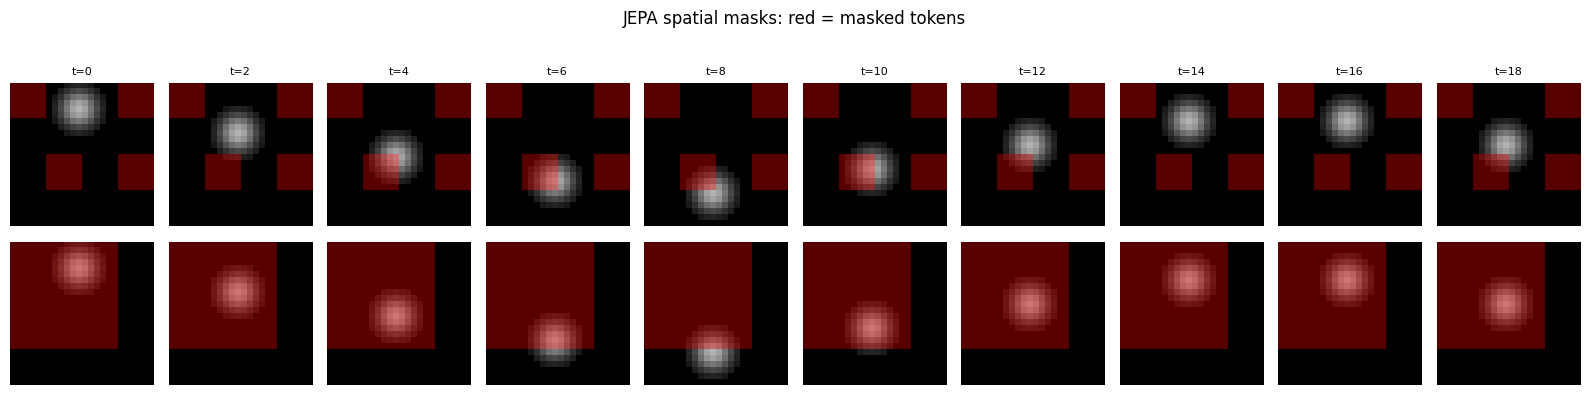

In [9]:
num_frames = N_FRAMES
batch_size = 8
patch_size = 6
image_size = 24
t_patch = 2

loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
batch = next(iter(loader))
if len(batch) == 4:
    _, videos, positions, velocities = batch
else:
    videos, positions, velocities = batch

t_grid = num_frames // t_patch
s_grid = image_size // patch_size

groups = sample_masks(videos.size(0), t_grid, s_grid)
n_groups = len(groups)

n_frames_total = videos.shape[2]
frame_indices = list(range(0, n_frames_total, 2))   # every 2nd frame
n_display_frames = len(frame_indices)

sample_i = 0
fig, axes = plt.subplots(n_groups, n_display_frames,
                         figsize=(1.6 * n_display_frames, 2.0 * n_groups),
                         squeeze=False)

for row, group in enumerate(groups):
    masked_spatial = np.unique(np.array(group["pred"][sample_i]) % (s_grid * s_grid))
    mask_grid = np.zeros((s_grid, s_grid), dtype=bool)
    mask_grid.flat[masked_spatial] = True
    mask_pixels = np.repeat(np.repeat(mask_grid, patch_size, axis=0), patch_size, axis=1)

    for col, t in enumerate(frame_indices):
        ax = axes[row, col]
        ax.imshow(videos[sample_i, 0, t].cpu(), cmap="gray", vmin=0, vmax=1)
        overlay = np.zeros((*mask_pixels.shape, 4))
        overlay[mask_pixels] = [1, 0, 0, 0.35]
        ax.imshow(overlay)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(group["label"], rotation=0, ha="right", va="center")
        if row == 0:
            ax.set_title(f"t={t}", fontsize=8)

plt.suptitle("JEPA spatial masks: red = masked tokens", y=1.02)
plt.tight_layout()
plt.show()

### The Encoder

With tokenization defined, the next step is turning those tokens into representations, this is where the encoder itself lives.

The building blocks here are self-attention transformer blocks: each token looks at every other token in the sequence and decides how much to weight each one when updating its own representation, letting information flow between distant patches directly, rather than only through the fixed, local neighborhoods a convolutional network would use. Transformers have no inherent sense of position, though: attention treats a sequence of tokens as an unordered set unless told otherwise. `pos_embed_3d` fixes this by giving every token a fixed sin/cos embedding based on where it sits in space and time, the same idea used in the original Transformer paper, extended here from one dimension to three. `Block` is the standard building block used throughout this notebook: self-attention followed by an MLP, both with residual connections. The same class reappears in the predictor later.

`VideoEncoder` ties it together: `tubelet_proj` turns the clip into tubelet tokens, positional embeddings get added, and the result runs through a stack of `Block`s. Its `forward` method supports more than one use case on purpose: encoding the whole clip at once (the default), encoding a single temporal group in isolation via `t_offset` (used later to keep the rollout predictor from leaking information from future frames), and encoding only a subset of tokens via `idx` (used for masking, this is what the context encoder calls with only the visible tokens). The same class serves as both the context encoder and the target encoder, just used differently.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

def pos_embed_3d(t, h, w, dim, t_frac=0.25):
    """Combined temporal + spatial sin/cos positional embedding for video tokens."""
    td = int(dim * t_frac); td += td % 2; sd = dim - td

    # Temporal component
    pos_t = torch.arange(t).unsqueeze(1).float()
    div_t = torch.exp(torch.arange(0, td, 2).float() * (-math.log(10000.) / td))
    pe_t = torch.zeros(t, td)
    pe_t[:, 0::2] = torch.sin(pos_t * div_t)
    pe_t[:, 1::2] = torch.cos(pos_t * div_t)

    # Spatial component
    sub = sd // 4
    yy, xx = [x.reshape(-1).float() for x in torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")]
    div_s = torch.exp(torch.arange(0, sub * 2, 2).float() * (-math.log(10000.) / (sub * 2)))
    pe_s = torch.cat([torch.sin(yy[:, None] * div_s), torch.cos(yy[:, None] * div_s),
                       torch.sin(xx[:, None] * div_s), torch.cos(xx[:, None] * div_s)], dim=-1)

    # Combine: broadcast temporal across all spatial positions, spatial across all timesteps
    pe = torch.zeros(t * h * w, dim)
    pe[:, :td] = pe_t.unsqueeze(1).expand(t, h * w, td).reshape(-1, td)
    pe[:, td:] = pe_s.unsqueeze(0).expand(t, h * w, sd).reshape(-1, sd)
    return pe

class Block(nn.Module):
    def __init__(self, dim, heads, mlp=4.0):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(dim, eps=1e-6), nn.LayerNorm(dim, eps=1e-6)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(dim, int(dim * mlp)), nn.GELU(), nn.Linear(int(dim * mlp), dim))

    def forward(self, x, attn_mask=None):
        h = self.n1(x)
        x = x + self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)[0]
        return x + self.mlp(self.n2(x))


class VideoEncoder(nn.Module):
    def __init__(self, num_frames=20, t_patch=2, img_size=24, patch_size=6,
                 in_chans=1, dim=128, depth=6, heads=4):
        super().__init__()
        self.t_grid = num_frames // t_patch; self.s_grid = img_size // patch_size
        self.n_patches = self.t_grid * self.s_grid * self.s_grid
        self.t_patch = t_patch; self.patch_size = patch_size; self.dim = dim
        self.tubelet_proj = nn.Conv3d(in_chans, dim,
                                      kernel_size=(t_patch, patch_size, patch_size),
                                      stride=(t_patch, patch_size, patch_size))
        self.register_buffer("pos", pos_embed_3d(self.t_grid, self.s_grid, self.s_grid, dim))
        self.blocks = nn.ModuleList([Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim, eps=1e-6)


    def forward(self, videos, idx=None, t_offset=0):
        tokens = self.tubelet_proj(videos).flatten(2).transpose(1, 2)
        B, N, D = tokens.shape

        if idx is None:
            S = self.s_grid * self.s_grid
            if N == S:
                # Single-group encode (e.g. leakage-safe rollout encoding)
                idx = torch.arange(t_offset * S, t_offset * S + N, device=videos.device).expand(B, -1)
            else:
                # Full-clip encode (default path, N = T*S)
                idx = torch.arange(N, device=videos.device).expand(B, -1)
            x = tokens + self.pos[idx]
        else:
            x = tokens.gather(1, idx.unsqueeze(-1).expand(-1, -1, D)) + self.pos[idx]

        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)


### The Predictor

The predictor's job, as described earlier, is to infer the representation of the masked positions from the visible ones. Concretely: the encoded context tokens are projected down to the predictor's own, smaller, working dimension, and every masked position gets filled with a copy of the same learnable `mask_token`, a placeholder that carries no information about what's actually there, only its position, added the same way positional embeddings were added in the encoder. Context tokens and mask tokens are concatenated into one sequence and run through the same kind of self-attention blocks as the encoder, letting the mask tokens attend to the visible context, and to each other, to infer what should fill each gap. Only the mask-token positions are read out at the end and projected back up to the encoder's dimension, giving the predicted representation for each masked position.

In [11]:
class Predictor(nn.Module):
    def __init__(self, t_grid, s_grid, enc_dim=128, dim=64, depth=4, heads=4):
        super().__init__()
        self.in_proj = nn.Linear(enc_dim, dim); self.out_proj = nn.Linear(dim, enc_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dim)); nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.register_buffer("pos", pos_embed_3d(t_grid, s_grid, s_grid, dim))
        self.blocks = nn.ModuleList([Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim, eps=1e-6)

    def forward(self, ctx, ctx_idx, tgt_idx):
        B, T = ctx.size(0), tgt_idx.size(1)
        x = torch.cat([self.in_proj(ctx) + self.pos[ctx_idx],
                       self.mask_token.expand(B, T, -1) + self.pos[tgt_idx]], dim=1)
        for blk in self.blocks: x = blk(x)
        return self.out_proj(self.norm(x[:, -T:]))

### The Pretraining Model

`PretrainingModel` assembles everything from this section into one trainable object: a context encoder, an EMA-updated target encoder, and a predictor.

Each training step samples a fresh short-range and long-range mask, encodes the context video using only its visible tokens, and asks the predictor to infer the masked positions' representations. Those predictions are compared against the target encoder's own encoding of the complete, clean, unmasked clip, using a simple L1 distance in representation space. Both mask groups are trained on in the same step; their losses are logged separately, since long-range masking is the harder of the two tasks and it's worth seeing whether the model struggles more with one than the other.

`update_target` implements the exponential moving average described earlier: the first call copies the context encoder's weights over directly, so both encoders start identical, and every call after that nudges the target encoder a small step toward the context encoder's current weights, keeping the prediction target stable and slow-moving rather than tied to whatever the context encoder looks like at this exact instant.

In [12]:
import deeplay as dl

class PretrainingModel(dl.Application):
    def __init__(self, num_frames=N_FRAMES, img_size=IMAGE_SIZE, t_patch=2, patch_size=6,
                 dim=128, depth=6, heads=4, ema_tau=0.998, optimizer=None, **kwargs):

        self.ctx_enc = VideoEncoder(num_frames=num_frames, t_patch=t_patch, img_size=img_size,
                                     patch_size=patch_size, dim=dim, depth=depth, heads=heads)
        self.tgt_enc = VideoEncoder(num_frames=num_frames, t_patch=t_patch, img_size=img_size,
                                     patch_size=patch_size, dim=dim, depth=depth, heads=heads)
        for p in self.tgt_enc.parameters():
            p.requires_grad_(False)

        self.predictor = Predictor(t_grid=self.ctx_enc.t_grid, s_grid=self.ctx_enc.s_grid, enc_dim=dim)

        self.ema_tau = ema_tau
        self._target_synced = False

        super().__init__(**kwargs)

        self.optimizer = optimizer or dl.Adam(lr=3e-4)

        @self.optimizer.params
        def params(self):
            return self.parameters()

    def _shared_step(self, batch, stage):
        if len(batch) == 4:
            # videos_clean, videos_ctx, _, _ = batch
            _, videos_ctx, _, _ = batch
            videos_clean = videos_ctx            
        else:
            videos_clean, _, _ = batch
            videos_ctx = videos_clean

        device = videos_ctx.device
        D = self.ctx_enc.dim

        groups = sample_masks(videos_ctx.size(0), self.ctx_enc.t_grid, self.ctx_enc.s_grid)

        with torch.no_grad():
            full_tgt = F.layer_norm(self.tgt_enc(videos_clean), (D,))

        losses = {}
        for g in groups:
            ci = torch.tensor(g["ctx"], device=device)
            ti = torch.tensor(g["pred"], device=device)
            tgt_tokens = full_tgt.gather(1, ti.unsqueeze(-1).expand(-1, -1, D))
            pred_tokens = self.predictor(self.ctx_enc(videos_ctx, ci), ci, ti)
            losses[g["label"]] = F.l1_loss(pred_tokens, tgt_tokens)

        for name, v in losses.items():
            self.log(f"{stage}_{name}_loss", v, on_step=True, on_epoch=True, prog_bar=True, logger=True)

        return sum(losses.values()) / len(losses)

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def on_train_batch_end(self, outputs, batch, batch_idx):
        self.update_target()

    @torch.no_grad()
    def update_target(self):
        if not self._target_synced:
            self.tgt_enc.load_state_dict(self.ctx_enc.state_dict())
            self._target_synced = True
            return
        for p, pt in zip(self.ctx_enc.parameters(), self.tgt_enc.parameters()):
            pt.data.mul_(self.ema_tau).add_(p.data, alpha=1 - self.ema_tau)

Let's make pretraining actually happen.

In [13]:
model = PretrainingModel(ema_tau=0.999, optimizer=dl.Adam(lr=3e-4))
summary = model.fit(train_ds, max_epochs=30, batch_size=16, accelerator="auto")

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ ctx_enc       │ VideoEncoder     │  1.2 M │ train │     0 │
│ 1 │ tgt_enc       │ VideoEncoder     │  1.2 M │ train │     0 │
│ 2 │ predictor     │ Predictor        │  216 K │ train │     0 │
│ 3 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 1.2 M                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 161                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Let's define a reusable helper for the loss curves...

In [14]:
def plot_loss_curves(summary, keys, titles=None, figsize=None):
    """Plot one subplot per loss key substring found in `summary.history`.

    `keys` is a list of substrings to search for (e.g. ["short", "long"]
    for pretraining, or ["tf", "roll"] for rollout later).
    """
    n = len(keys)
    titles = titles or keys
    fig, axes = plt.subplots(1, n, figsize=figsize or (5.5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, key_substr, title in zip(axes, keys, titles):
        for key in summary.history.keys():
            if key_substr in key and key.endswith("_epoch"):
                ax.plot(summary.history[key]["value"], label=key)
        ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title(title)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

... and display the curves.

Both curves show a similar shape: a sharp early drop, a rise, then a slow decline. The initial drop isn't genuine learning, it's representation collapse: early in training, the untrained predictor's gradients can pull the encoder toward mapping every input to nearly the same constant representation, which is trivially easy to "predict" and drives the loss down fast for the wrong reason. As the EMA-updated target stabilizes and the representation starts differentiating again, escaping that collapse, the loss rises, before beginning a slower, genuine decline as the model actually learns to solve the masked-prediction task (Ennadir, Zólyomi, and Smirnov, 2026).

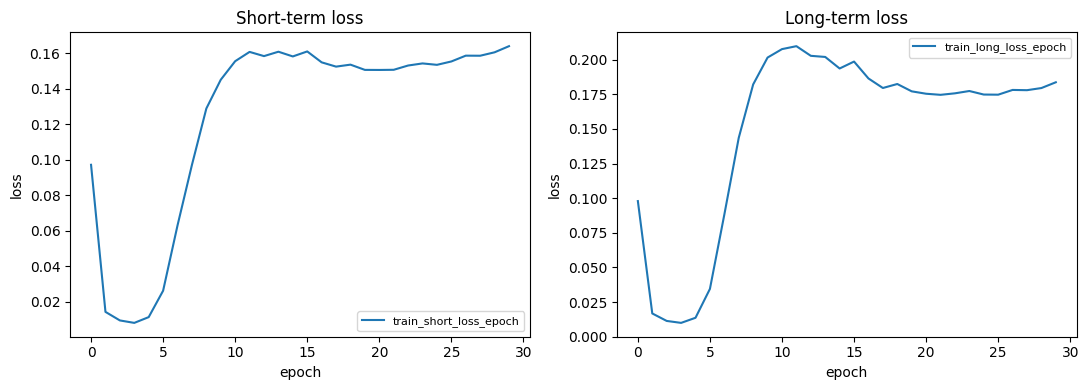

In [15]:
plot_loss_curves(summary, keys=["short", "long"], titles=["Short-term loss", "Long-term loss"])

### Evaluating the Representation with Linear Probing

Up to this point, the model was trained without ever being told what position or velocity are. 

> So how do you check whether that self-supervised representation actually captured them?

The standard approach in self-supervised learning is linear probing: freeze the trained encoder entirely, and fit a simple linear model on top of its output to predict the quantity of interest, using a small amount of labeled data the encoder itself never saw during training. The key word is linear. A powerful, nonlinear probe could potentially extract position and velocity from almost any representation, however disorganized, by doing the hard work of reconstruction itself, which would say more about the probe than about the representation. A linear probe has no such flexibility: if it succeeds, that's evidence the encoder already arranged the information in an accessible, roughly linear way on its own, without ever being asked to.

Let's check what the representation actually captured. `collect_ctx_features_per_frame` runs the context encoder directly on each unmasked clip and pools the per-timestep tokens into one vector per frame.

In [16]:
device = next(model.parameters()).device
model.eval()

@torch.no_grad()
def collect_ctx_features_per_frame(ctx_enc, dataloader, device="cpu"):
    """Run the frozen context encoder over a dataset in batches, pooling
    per-timestep tokens into one feature vector per frame."""
    ctx_enc.eval()
    t_grid, s_grid = ctx_enc.t_grid, ctx_enc.s_grid
    S = s_grid * s_grid

    Z, pos, vel = [], [], []
    for batch in dataloader:
        if len(batch) == 4:
            _, videos, positions, velocities = batch
        else:
            videos, positions, velocities = batch
        B = videos.size(0)
        videos = videos.to(device)

        tokens = ctx_enc(videos)                    # (B, T*S, D)
        tokens = tokens.view(B, t_grid, S, -1)
        z_per_t = tokens.mean(dim=2)                 # pool over space -> (B, T, D)

        Z.append(z_per_t.cpu().numpy())
        pos.append(torch.stack([positions[:, t * ctx_enc.t_patch] for t in range(t_grid)], dim=1).numpy())
        vel.append(torch.stack([velocities[:, t * ctx_enc.t_patch] for t in range(t_grid)], dim=1).numpy())

    return np.concatenate(Z, axis=0), np.concatenate(pos, axis=0), np.concatenate(vel, axis=0)

Here, you'll define a helper to fit one Ridge regression per timestep on a validation set, then scoring it on a held-out test set the probe has never seen either. 

In [17]:
from sklearn.linear_model import Ridge

def fit_and_score_probes(model, val_ds, test_ds, device, batch_size=32, alpha=1.0, verbose=True):
    """Fit a per-timestep Ridge probe on validation features, score it on
    held-out test features, for both position and velocity."""
    val_dataloader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_dataloader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    Z_val, pos_val, vel_val = collect_ctx_features_per_frame(model.ctx_enc, val_dataloader, device=device)
    Z_test, pos_test, vel_test = collect_ctx_features_per_frame(model.ctx_enc, test_dataloader, device=device)

    t_grid = model.ctx_enc.t_grid
    probes_pos, probes_vel = [], []
    r2_pos, r2_vel = [], []
    for t in range(t_grid):
        p_pos = Ridge(alpha=alpha).fit(Z_val[:, t, :], pos_val[:, t, :])
        p_vel = Ridge(alpha=alpha).fit(Z_val[:, t, :], vel_val[:, t, :])
        probes_pos.append(p_pos); probes_vel.append(p_vel)

        s_pos = p_pos.score(Z_test[:, t, :], pos_test[:, t, :])
        s_vel = p_vel.score(Z_test[:, t, :], vel_test[:, t, :])
        r2_pos.append(s_pos); r2_vel.append(s_vel)

        if verbose:
            print(f"Frame {t * model.ctx_enc.t_patch:2d}: pos R²={s_pos:.3f}, vel R²={s_vel:.3f}")

    return probes_pos, probes_vel, r2_pos, r2_vel

The score is R², the fraction of variance in the true position or velocity that the probe's predictions account for: 1.0 means perfect prediction, 0.0 means no better than always guessing the average value, and it can go negative if the probe does worse than that baseline. 

If position and velocity come out linearly decodable this way, from a representation trained with no labels at all, that's the actual claim this notebook has been building toward: that a JEPA-style encoder can recover the state of a physical system directly from pixels, without any supervision.

In [18]:
print("--- Pretraining probes, clean clips ---")
probes_pos, probes_vel, r2_pos, r2_vel = fit_and_score_probes(model, val_ds, test_ds, device)

--- Pretraining probes, clean clips ---
Frame  0: pos R²=0.965, vel R²=0.649
Frame  2: pos R²=0.973, vel R²=0.754
Frame  4: pos R²=0.976, vel R²=0.775
Frame  6: pos R²=0.978, vel R²=0.817
Frame  8: pos R²=0.983, vel R²=0.779
Frame 10: pos R²=0.982, vel R²=0.836
Frame 12: pos R²=0.979, vel R²=0.805
Frame 14: pos R²=0.980, vel R²=0.819
Frame 16: pos R²=0.981, vel R²=0.808
Frame 18: pos R²=0.980, vel R²=0.788


Position R² sits at 0.96–0.98 across every single frame, remarkably stable, while velocity, always the harder quantity to recover since it requires integrating information across time rather than reading off a single instant, still reaches 0.77–0.85 for most of the clip. This is a representation that was never given a single labeled example during pretraining; decoding it this well with a linear probe is the actual evidence that self-supervised masked prediction organized position and velocity into the representation on its own.

### Visualizing Probe Predictions

It's also worth seeing what the probes actually predict, frame by frame, and how far off they are.

The helper `prepare_pretraining_predictions` picks a handful of random test clips, encodes them, and applies the per-timestep probes to produce predicted positions and velocities alongside the ground truth.

In [19]:
def prepare_pretraining_predictions(model, dataset, probes_pos, probes_vel, device, num_examples=3):
    """Pick random examples, run the frozen context encoder, and apply the
    per-timestep probes -- assembling arrays for plot_predictions_with_velocity.
    """
    t_grid, s_grid = model.ctx_enc.t_grid, model.ctx_enc.s_grid
    S = s_grid * s_grid
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    videos_np, positions_np, velocities_np = [], [], []
    pred_positions, pred_velocities = [], []

    with torch.no_grad():
        for i in indices:
            if dataset[0].__len__() == 4:
                _, video, positions, velocities = dataset[i]
            else:
                video, positions, velocities = dataset[i]
            video_b = video.unsqueeze(0).to(device)

            tokens = model.ctx_enc(video_b)
            tokens = tokens.view(t_grid, S, -1)
            z_per_t = tokens.mean(dim=1).cpu().numpy()

            videos_np.append(video.numpy())
            positions_np.append(positions.numpy())
            velocities_np.append(velocities.numpy())
            pred_positions.append([probes_pos[t].predict(z_per_t[t:t+1])[0] for t in range(t_grid)])
            pred_velocities.append([probes_vel[t].predict(z_per_t[t:t+1])[0] for t in range(t_grid)])

    videos_np, positions_np, velocities_np = map(np.array, (videos_np, positions_np, velocities_np))
    pred_positions, pred_velocities = map(np.array, (pred_positions, pred_velocities))
    target_frame_indices = [t * model.ctx_enc.t_patch for t in range(t_grid)]

    return videos_np, positions_np, velocities_np, target_frame_indices, pred_positions, pred_velocities

The helper `plot_predictions_with_velocity` then renders each clip's frames with both the ground-truth and predicted bead position and velocity drawn on top.

In [20]:
def plot_predictions_with_velocity(videos_np, positions_np, velocities_np,
                                    target_frame_indices,
                                    pred_positions, pred_velocities,
                                    context_frame_idx=None,
                                    title_prefix=""):
    """
    context_frame_idx: if None, no context column is drawn (masked case).
    """
    num_examples, n_steps = pred_positions.shape[:2]
    has_context = context_frame_idx is not None
    total_cols = (1 if has_context else 0) + n_steps
    fig, axes = plt.subplots(num_examples, total_cols, figsize=(3 * total_cols, 3 * num_examples))
    axes = np.atleast_2d(axes).reshape(num_examples, total_cols)

    for row in range(num_examples):
        col = 0
        axes[row, 0].set_ylabel(f"Ex {row + 1}", fontsize=11, fontweight="bold")

        if has_context:
            ax_ctx = axes[row, col]
            ax_ctx.imshow(videos_np[row, 0, context_frame_idx], cmap="gray", vmin=0, vmax=1)
            gt_pos0 = positions_np[row, context_frame_idx]
            gt_vel0 = velocities_np[row, context_frame_idx]
            ax_ctx.scatter(gt_pos0[1], gt_pos0[0], color="tab:green", edgecolors="black", s=80, label="GT")
            ax_ctx.quiver(gt_pos0[1], gt_pos0[0], gt_vel0[1], gt_vel0[0],
                          angles='xy', scale_units='xy', scale=0.5, color='tab:green', width=0.015, headwidth=3)
            if row == 0:
                ax_ctx.set_title(f"Context (t={context_frame_idx})", fontsize=12, fontweight="bold")
            ax_ctx.axis("off")
            col += 1

        for step, frame_idx in enumerate(target_frame_indices):
            ax = axes[row, col]
            ax.imshow(videos_np[row, 0, frame_idx], cmap="gray", vmin=0, vmax=1)

            gt_pos, gt_vel = positions_np[row, frame_idx], velocities_np[row, frame_idx]
            ax.scatter(gt_pos[1], gt_pos[0], color="tab:green", edgecolors="black", s=80)
            ax.quiver(gt_pos[1], gt_pos[0], gt_vel[1], gt_vel[0],
                      angles='xy', scale_units='xy', scale=0.5, color='tab:green', width=0.015, headwidth=3)

            pp, pv = pred_positions[row, step], pred_velocities[row, step]
            ax.scatter(pp[1], pp[0], color="tab:red", marker="x", s=90, linewidths=2, label="Predicted")
            ax.quiver(pp[1], pp[0], pv[1], pv[0],
                      angles='xy', scale_units='xy', scale=0.5, color='tab:red', width=0.015, headwidth=3)

            if row == 0:
                ax.set_title(f"{title_prefix}(t={frame_idx})", fontsize=12, fontweight="bold")
            ax.axis("off")
            col += 1

    axes[0, 0].legend(loc="upper left", bbox_to_anchor=(0, 1.3), ncol=2, frameon=True)
    plt.tight_layout()
    plt.show()

Below you'll take a few test clips, encode them with the frozen context encoder, read out position and velocity at each timestep with the fitted probes, and overlay ground-truth and predicted values on the frames.

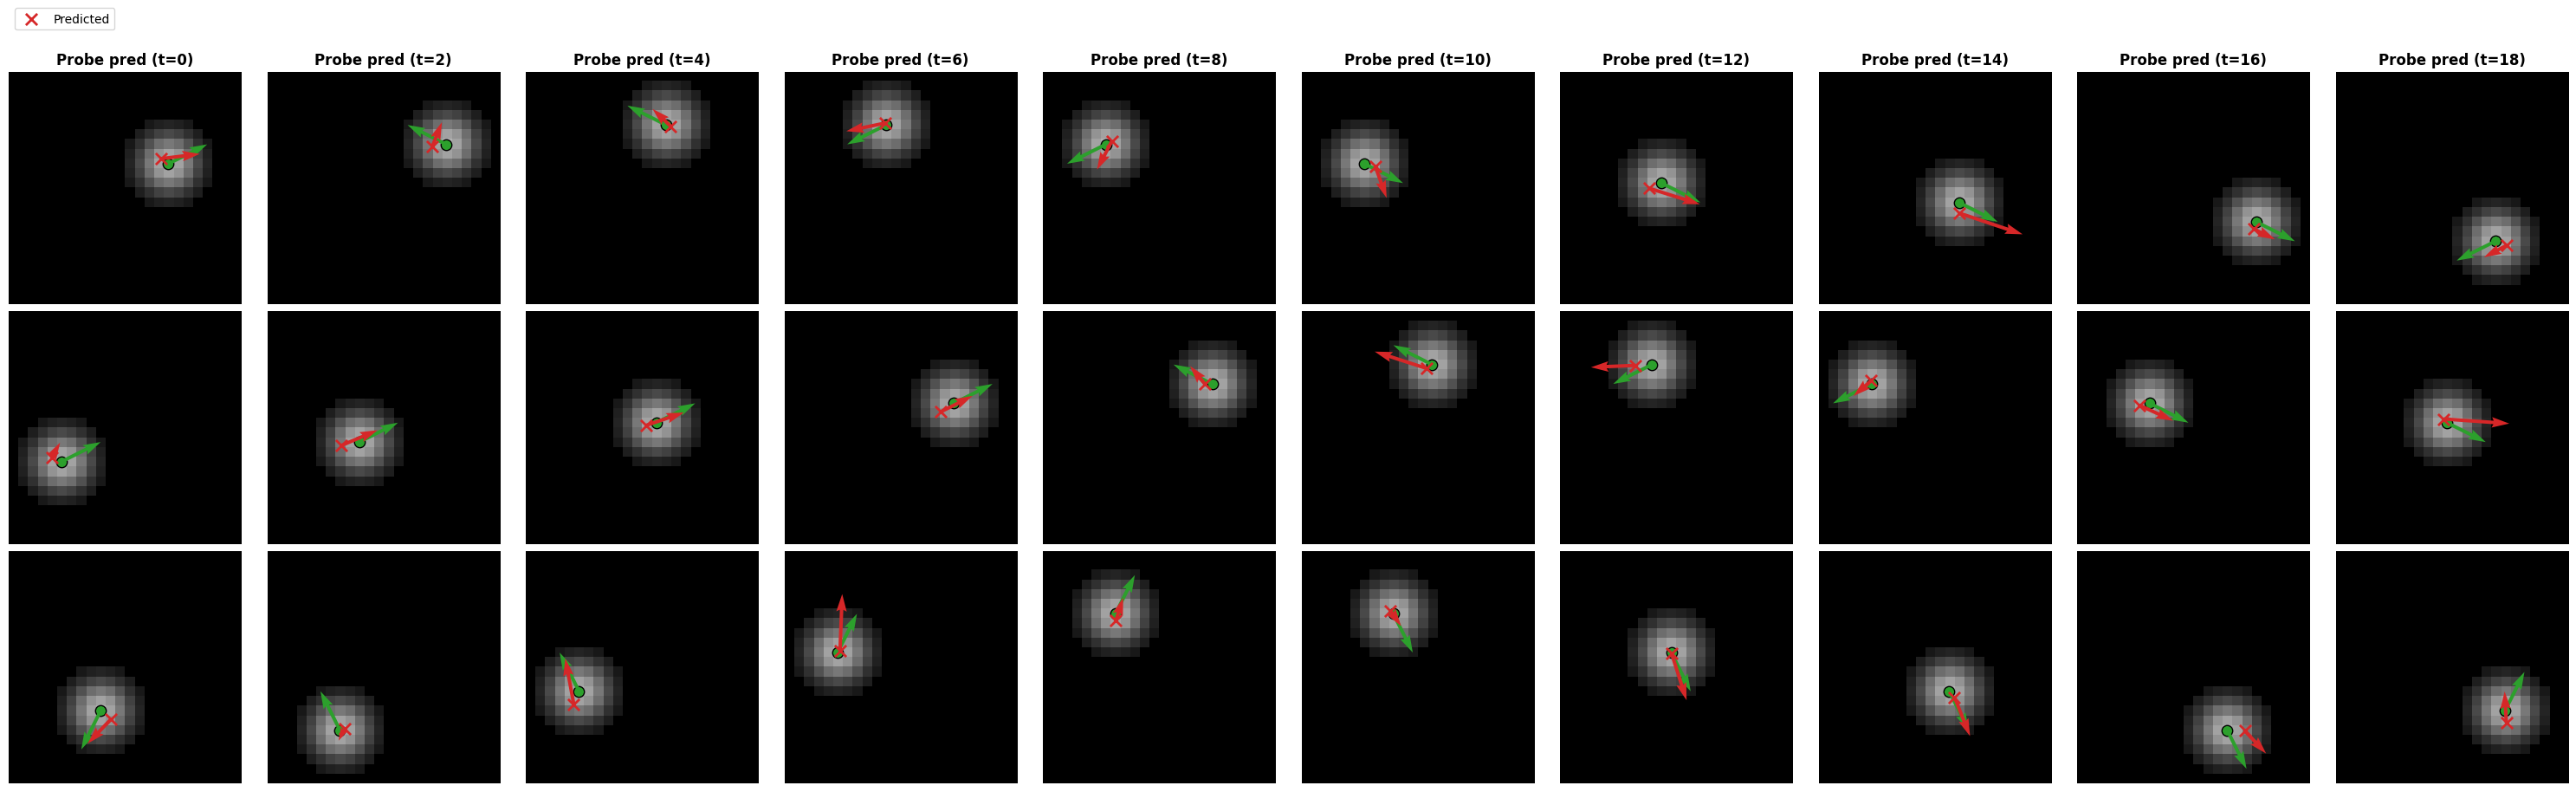

In [21]:
videos_np, positions_np, velocities_np, target_frame_indices, pred_positions, pred_velocities = \
    prepare_pretraining_predictions(model, test_ds, probes_pos, probes_vel, device, num_examples=3)

plot_predictions_with_velocity(
    videos_np, positions_np, velocities_np,
    target_frame_indices=target_frame_indices,
    pred_positions=pred_positions, pred_velocities=pred_velocities,
    context_frame_idx=None,
    title_prefix="Probe pred ",
)

### Curriculum Learning: Adding Distractors

So far you've trained only on clean clips. To bring in distractors without destabilizing what the model has already learned, you'll use curriculum learning: rather than exposing a model to the full difficulty of a task from the start, training begins on an easier version of the problem, and harder examples are introduced only once the model has settled into a stable representation.

Here that means starting from the model already pretrained on clean clips and continuing its training on clips with distractors, rather than training on distractors from scratch. In practice, this means loading a distractor version of the same dataset (`p_distractors=1.0`) and calling `model.fit` again on that same `model` instance.

In [22]:
train_ds_w = ParticlesDataset("datasets/bouncing bead with distractors/particles_train.pt", p_distractors=1.0, seed=0)
val_ds_w = ParticlesDataset("datasets/bouncing bead with distractors/particles_val.pt", p_distractors=1.0, seed=0)
test_ds_w = ParticlesDataset("datasets/bouncing bead with distractors/particles_test.pt", p_distractors=1.0, seed=0)

summary_cl = model.fit(train_ds_w, max_epochs=10, batch_size=16, accelerator="auto")

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ ctx_enc       │ VideoEncoder     │  1.2 M │ train │     0 │
│ 1 │ tgt_enc       │ VideoEncoder     │  1.2 M │ train │     0 │
│ 2 │ predictor     │ Predictor        │  216 K │ train │     0 │
│ 3 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 1.2 M                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 161                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Let's check the losses...

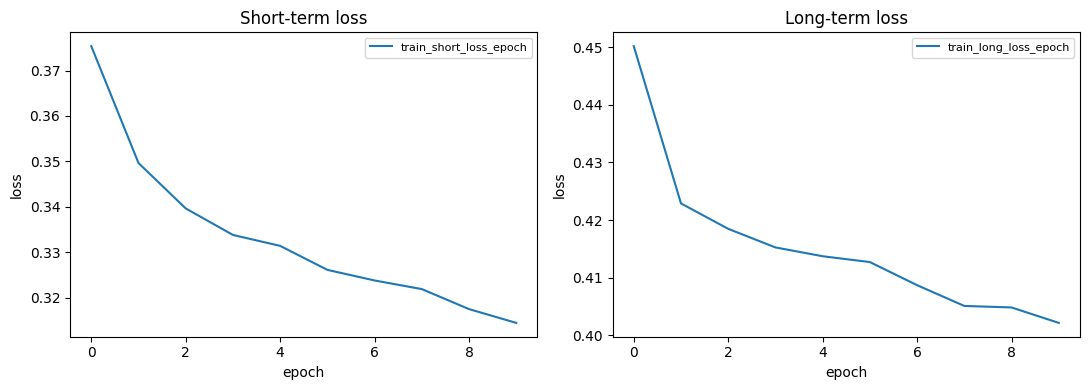

In [23]:
plot_loss_curves(summary_cl, keys=["short", "long"], titles=["Short-term loss", "Long-term loss"])

... the R² score...

In [24]:
print("--- Pretraining probes, with distractors ---")
probes_pos, probes_vel, r2_pos, r2_vel = fit_and_score_probes(model, val_ds_w, test_ds_w, device)

--- Pretraining probes, with distractors ---
Frame  0: pos R²=0.850, vel R²=0.361
Frame  2: pos R²=0.883, vel R²=0.463
Frame  4: pos R²=0.896, vel R²=0.569
Frame  6: pos R²=0.915, vel R²=0.617
Frame  8: pos R²=0.918, vel R²=0.533
Frame 10: pos R²=0.911, vel R²=0.618
Frame 12: pos R²=0.900, vel R²=0.658
Frame 14: pos R²=0.895, vel R²=0.654
Frame 16: pos R²=0.903, vel R²=0.571
Frame 18: pos R²=0.894, vel R²=0.546


... and visualize a few examples.

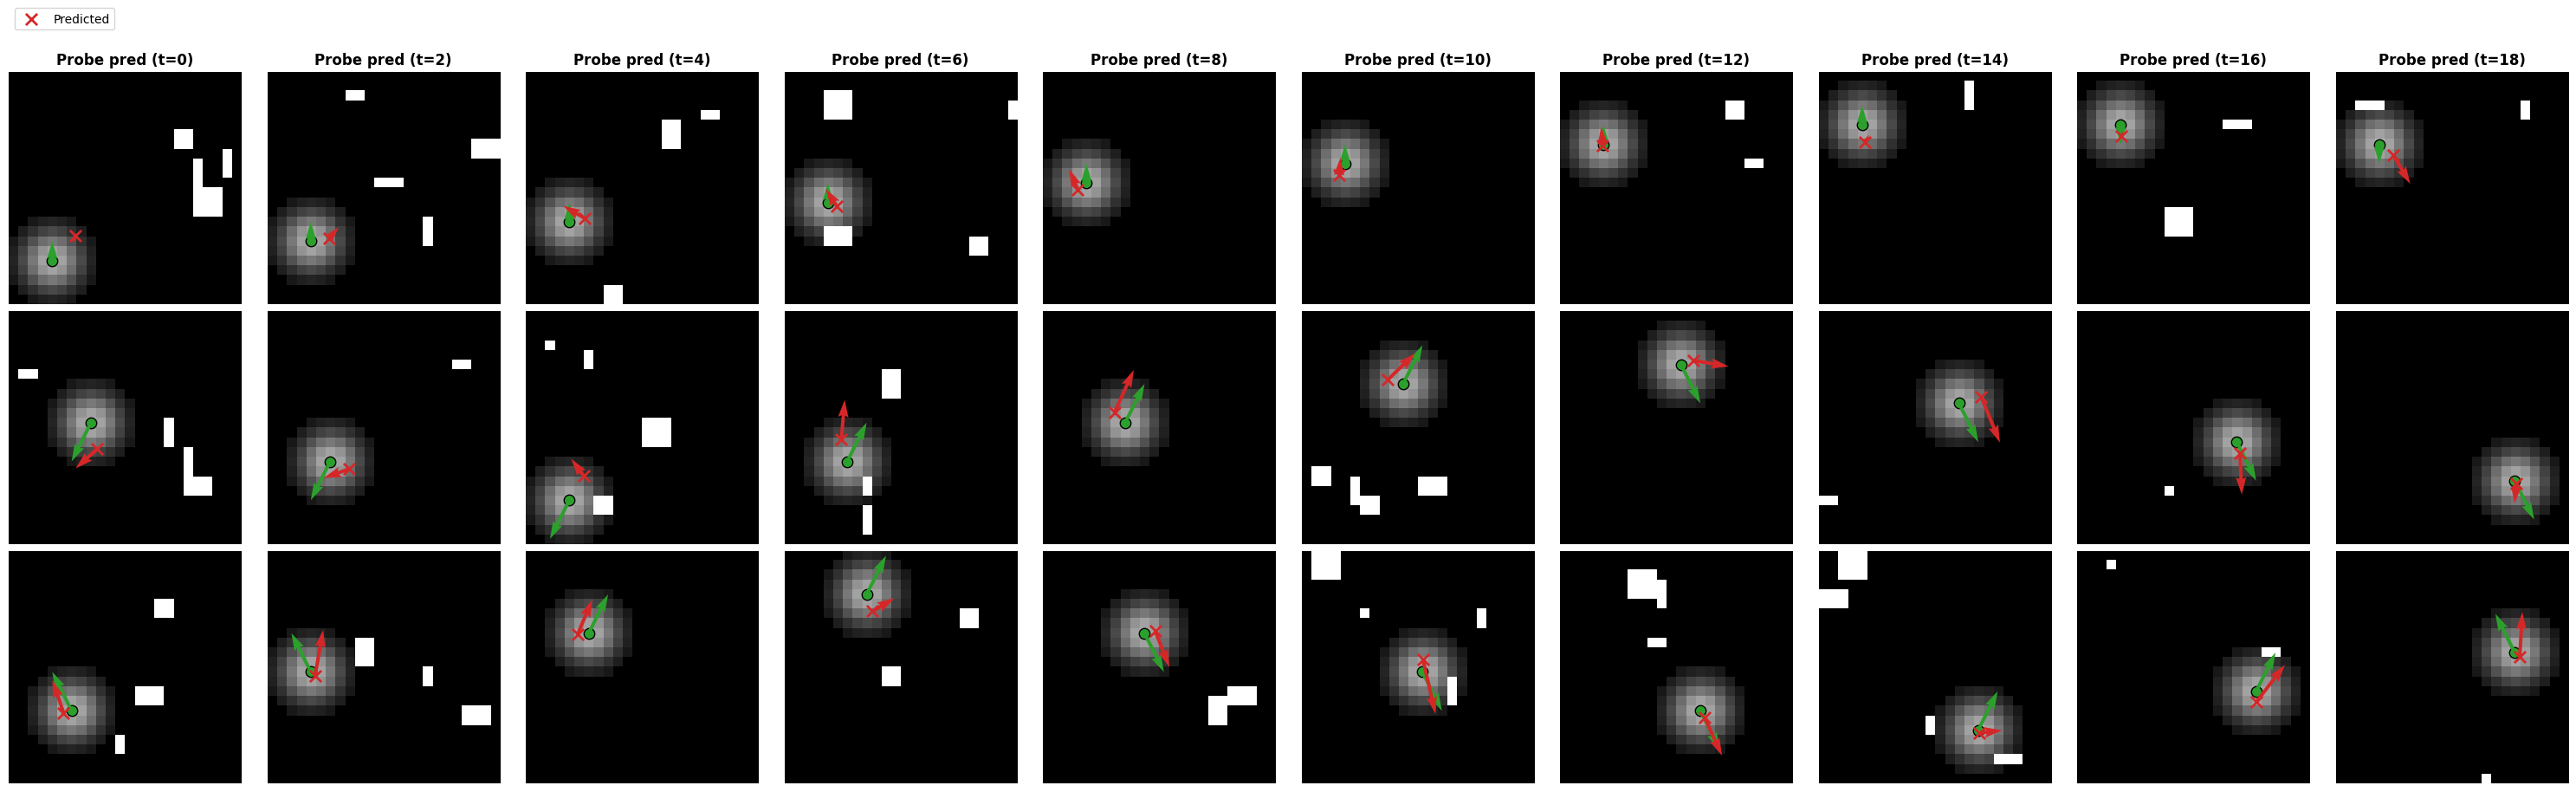

In [25]:
videos_np, positions_np, velocities_np, target_frame_indices, pred_positions, pred_velocities = \
    prepare_pretraining_predictions(model, test_ds_w, probes_pos, probes_vel, device, num_examples=3)

plot_predictions_with_velocity(
    videos_np, positions_np, velocities_np,
    target_frame_indices=target_frame_indices,
    pred_positions=pred_positions, pred_velocities=pred_velocities,
    context_frame_idx=None,
    title_prefix="Probe pred ",
)

## Rollout

Pretraining leaves you with an encoder that turns individual frames into representations carrying position and velocity information, useful, but only a snapshot description of a single instant. Rollout, the second stage of training, teaches a predictor to evolve those representations forward in latent space over multiple steps, so the model can imagine several timesteps ahead rather than just recover the present.

The context encoder is frozen at this stage. It already produces good per-frame representations, so Rollout only trains a new module, `RolloutPredictor`, to model how those representations change over time.

### The Rollout Predictor

`RolloutPredictor` is a transformer over the sequence of per-frame latents, structured to make prediction autoregressive: it uses block-causal attention, so each timestep's tokens can attend to their own and all earlier timesteps, but never later ones. A prediction for timestep t+1 never has access to information from t+1 onward. This is a different masking scheme from the `Predictor` used in pretraining, which hides a subset of *spatial* tokens within a single, fixed clip; here masking is *temporal* and causal, restricting what the model can see going forward in time rather than which patches are visible at one instant.

Its `rollout` method applies this autoregressively: given a single starting latent, it predicts the next timestep, appends that prediction to the sequence, and repeats, extending the latent trajectory one step at a time for as many steps as requested.

In [26]:
class RolloutPredictor(nn.Module):
    """Block-causal predictor, NO action/state conditioning -- pure passive
    dynamics: given latents for timesteps 0..t, predict timestep t+1.
    """
    
    def __init__(self, t_grid, s_grid, enc_dim=128, dim=128, depth=4, heads=4):
        super().__init__()
        self.t_grid = t_grid
        self.s_grid = s_grid
        self.in_proj = nn.Linear(enc_dim, dim)
        self.out_proj = nn.Linear(dim, enc_dim)
        self.register_buffer("pos", pos_embed_3d(t_grid, s_grid, s_grid, dim))
        self.blocks = nn.ModuleList([Block(dim, heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim, eps=1e-6)

    @staticmethod
    def _block_causal_mask(T, width, device):
        t = torch.arange(T, device=device).repeat_interleave(width)
        return t[:, None] < t[None, :]

    def forward(self, z):
        B, T, S, _ = z.shape
        x = self.in_proj(z) + self.pos[None, :T*S].view(1, T, S, -1)
        x = x.reshape(B, T * S, -1)
        mask = self._block_causal_mask(T, S, z.device)
        for blk in self.blocks:
            x = blk(x, mask)
        x = self.norm(x).view(B, T, S, -1)
        return self.out_proj(x)

    def rollout(self, z0, n_steps):
        z_seq = z0[:, None]   # (B, 1, S, enc_dim)
        out = []
        for _ in range(n_steps):
            pred = self.forward(z_seq)[:, -1]
            z_seq = torch.cat([z_seq, pred[:, None]], dim=1)
            out.append(pred)
        return torch.stack(out, dim=1)

### The Rollout Model

`RolloutModel` ties the rollout predictor to training, mirroring the role `PretrainingModel` played in the first stage. The context encoder, already trained and now frozen, is used only to produce latents; the only trainable module is `rollout_predictor`.

Each temporal group of frames is encoded separately, one encoder call per group, restricted to that group's own frames, rather than encoding the whole clip in a single pass. This guarantees no attention leakage across time at the encoding stage itself, before the causal predictor is even applied.

The loss combines two terms, matching V-JEPA2-AC's approach. `loss_tf` is a teacher-forced loss: given true latents at all timesteps up to T-2, predict the next one at every position simultaneously. `loss_roll` is a short autoregressive rollout: starting only from the first latent, the model predicts several steps forward on its own, each prediction built on prior predictions rather than ground truth, and compares the result to the true latent k steps ahead. Training on both keeps the model accurate at single-step prediction while also exposing it to the compounding error it will face at evaluation time, when only autoregressive rollout is available.

In [27]:
import copy

class RolloutModel(dl.Application):
    def __init__(self, frozen_ctx_enc, dim=128, depth=4, heads=4,
                 rollout_k=2, rollout_w=1.0, optimizer=None, **kwargs):
        self.encoder = copy.deepcopy(frozen_ctx_enc)
        for p in self.encoder.parameters():
            p.requires_grad_(False)

        self.rollout_predictor = RolloutPredictor(
            t_grid=self.encoder.t_grid, s_grid=self.encoder.s_grid,
            enc_dim=self.encoder.dim, dim=dim, depth=depth, heads=heads
        )

        self.rollout_k = rollout_k
        self.rollout_w = rollout_w

        super().__init__(**kwargs)
        self.optimizer = optimizer or dl.Adam(lr=3e-4)

        @self.optimizer.params
        def params(self):
            return self.rollout_predictor.parameters()

    def _shared_step(self, batch, stage):
        if len(batch) == 4:
             _, videos, _, _ = batch
        else:
            videos, _, _ = batch
        self.encoder.eval()
        B = videos.size(0)
        T, S = self.encoder.t_grid, self.encoder.s_grid ** 2
        t_patch = self.encoder.t_patch

        # Encode each temporal group SEPARATELY, each time restricted to only
        # its own frames -- no attention access to future frames at all.
        z_list = []
        with torch.no_grad():
            for t in range(T):
                frame_slice = videos[:, :, t * t_patch : (t + 1) * t_patch]  # (B, C, t_patch, H, W)
                tokens_t = self.encoder(frame_slice, t_offset=t)
                z_list.append(tokens_t.view(B, S, -1))
        z = torch.stack(z_list, dim=1)   # (B, T, S, D)

        preds = self.rollout_predictor(z[:, :-1])
        tgt = z[:, 1:]
        loss_tf = (preds - tgt).abs().mean()

        k = min(self.rollout_k, T - 1)
        rolled = self.rollout_predictor.rollout(z[:, 0], k)
        loss_roll = (rolled[:, -1] - z[:, k]).abs().mean()

        loss = loss_tf + self.rollout_w * loss_roll
        self.log(f"{stage}_tf", loss_tf, on_step=True, on_epoch=True, prog_bar=True)
        self.log(f"{stage}_roll", loss_roll, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")



Let's train. Only `rollout_predictor`'s parameters are updated, the encoder stays frozen throughout, and unlike pretraining, no curriculum is needed here: the encoder already learned to represent distractor clips during its own curriculum stage, so the rollout predictor can train directly on `train_ds_w` from the start.

In [28]:
rollout_model = RolloutModel(frozen_ctx_enc=model.ctx_enc, optimizer=dl.Adam(lr=3e-4))
summary_ro = rollout_model.fit(train_ds_w, max_epochs=100, batch_size=32, accelerator="auto")

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder           │ VideoEncoder     │  1.2 M │ train │     0 │
│ 1 │ rollout_predictor │ RolloutPredictor │  826 K │ train │     0 │
│ 2 │ train_metrics     │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics       │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics      │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer         │ Adam             │      0 │ train │     0 │
└───┴───────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 826 K                                                                                            
Non-trainable params: 1.2 M                                                                                        
Total params: 2.0 M                                                                                                
Total estimated model params size (MB): 8                                                                          
Modules in train mode: 103                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


SystemExit: 1

/Users/cmanzo/Documents/GitHub/Environments/deeptrack_dev/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Let's plot the losses...

In [ ]:
plot_loss_curves(summary_ro, keys=["tf", "roll"], titles=["Teacher-forcing loss", "Rollout loss"])

### Evaluating Rollout Predictions

To check whether the model's imagined future actually tracks the physical state of the bead, we need to compare the rollout predictor's latent predictions against the true position and velocity at each future step, the same linear-probing approach used for pretraining, but applied to predicted rather than directly encoded latents.

`extract_rollout_latents_and_targets` encodes only the first frame group, then lets `rollout_predictor.rollout` generate the next `n_steps` latents autoregressively, with no further access to the actual video. Each predicted latent is paired with the ground-truth position and velocity at its corresponding frame. Unlike the pretraining probes, which pooled each frame's tokens into a single feature vector, these features keep the full set of spatial tokens flattened together, since spatial detail may matter more once the model is predicting rather than just encoding.

In [ ]:
def extract_rollout_latents_and_targets(rollout_model, dataloader, n_steps=5):
    """Encodes only the first temporal group (frames 0..t_patch-1), then rolls 
    forward purely in latent space via rollout_predictor, so the model never 
    has direct access to future frames.
    """

    rollout_model.eval()
    rollout_model.encoder.eval()

    encoder = rollout_model.encoder
    t_patch = encoder.t_patch
    T, S, D = encoder.t_grid, encoder.s_grid ** 2, encoder.dim

    all_flat = []          # (n_samples, n_steps, S*D) -- no pooling, keep full spatial info
    all_positions = []     # (n_samples, n_steps, 2) -- true position at each rollout step's frame
    all_velocities = []

    with torch.no_grad():
        for batch in dataloader:
            if len(batch) == 4:
                _, videos, positions, velocities = batch
            else:
                videos, positions, velocities = batch
            B = videos.size(0)

            # Encode only the first temporal group -- everything after this
            # point is pure latent-space rollout, no further encoder calls.
            frame_slice = videos[:, :, :t_patch]
            z0 = encoder(frame_slice, t_offset=0)   # (B, S, D)

            rolled = rollout_model.rollout_predictor.rollout(z0, n_steps)   # (B, n_steps, S, D)
            flat = rolled.reshape(B, n_steps, S * D)

            # Ground truth at each rollout step's corresponding frame
            step_positions = torch.stack(
                [positions[:, (k + 1) * t_patch] for k in range(n_steps)], dim=1
            )  # (B, n_steps, 2)
            step_velocities = torch.stack(
                [velocities[:, (k + 1) * t_patch] for k in range(n_steps)], dim=1
            )

            all_flat.append(flat.cpu().numpy())
            all_positions.append(step_positions.cpu().numpy())
            all_velocities.append(step_velocities.cpu().numpy())

    return (np.concatenate(all_flat, axis=0),
            np.concatenate(all_positions, axis=0),
            np.concatenate(all_velocities, axis=0))

`fit_and_score_rollout_probes` mirrors `fit_and_score_probes` from pretraining, fit on validation, scored on held-out test, but one probe per rollout step instead of per frame, using the unpooled latents from `extract_rollout_latents_and_targets`. 

In [ ]:
def fit_and_score_rollout_probes(rollout_model, val_ds, test_ds, n_steps=None, batch_size=32, alpha=3.0, verbose=True):
    """Fit a per-rollout-step Ridge probe on validation latents, score it on
    held-out test latents, for both position and velocity."""
    val_dataloader = torch.utils.data.DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_dataloader = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    if n_steps is None:
        n_steps = rollout_model.encoder.t_grid - 1   # cover the whole clip

    X_val, Y_val, Z_val = extract_rollout_latents_and_targets(rollout_model, val_dataloader, n_steps=n_steps)
    X_test, Y_test, Z_test = extract_rollout_latents_and_targets(rollout_model, test_dataloader, n_steps=n_steps)

    t_patch = rollout_model.encoder.t_patch
    probes_pos, probes_vel = [], []
    r2_pos, r2_vel = [], []
    for step in range(X_val.shape[1]):
        p_pos = Ridge(alpha=alpha).fit(X_val[:, step, :], Y_val[:, step, :])
        p_vel = Ridge(alpha=alpha).fit(X_val[:, step, :], Z_val[:, step, :])
        probes_pos.append(p_pos); probes_vel.append(p_vel)

        s_pos = p_pos.score(X_test[:, step, :], Y_test[:, step, :])
        s_vel = p_vel.score(X_test[:, step, :], Z_test[:, step, :])
        r2_pos.append(s_pos); r2_vel.append(s_vel)

        if verbose:
            true_frame_idx = (step + 1) * t_patch
            print(f"Rollout Step {step+1} (frame {true_frame_idx}) -> Test R²: "
                  f"{s_pos:.3f} (Position), {s_vel:.3f} (Velocity)")

    return probes_pos, probes_vel, r2_pos, r2_vel

R² at step k measures how much position and velocity information survives k steps of autoregressive rollout, so a declining trend across steps is the expected signature of compounding error, not necessarily a failure.

In [ ]:
print("--- Strict Rollout Evaluation (Fit on Val, Score on Test, unpooled features) ---")
trained_probes_pos, trained_probes_vel, r2_pos_roll, r2_vel_roll = fit_and_score_rollout_probes(rollout_model, val_ds_w, test_ds_w)

### Visualizing Rollout Predictions

As with pretraining, `prepare_rollout_predictions` picks a few random test clips, rolls the encoded first frame group forward autoregressively, and reads out position and velocity at each step with the fitted rollout probes, assembling the same shape of arrays that `plot_predictions_with_velocity` expects, the same plotting helper from pretraining, reused as-is.

In [ ]:
def prepare_rollout_predictions(rollout_model, dataset, probes_pos, probes_vel, device, num_examples=3, n_steps=None):
    """Pick random examples, roll out the frozen encoder's latents
    autoregressively, and apply the per-step probes -- assembling arrays
    for plot_predictions_with_velocity.
    """

    encoder = rollout_model.encoder
    t_patch = encoder.t_patch
    S = encoder.s_grid ** 2

    if n_steps is None:
        n_steps = encoder.t_grid - 1   # cover the whole clip

    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    videos_np, positions_np, velocities_np = [], [], []
    pred_positions, pred_velocities = [], []

    with torch.no_grad():
        for i in indices:
            if dataset[0].__len__() == 4:
                _, video, positions, velocities = dataset[i]
            else:
                video, positions, velocities = dataset[i]
            video_b = video.unsqueeze(0).to(device)

            z0 = encoder(video_b[:, :, :t_patch], t_offset=0)          # (1, S, D)
            rolled = rollout_model.rollout_predictor.rollout(z0, n_steps)   # (1, n_steps, S, D)
            flat = rolled.reshape(n_steps, -1).cpu().numpy()            # (n_steps, S*D)

            videos_np.append(video.numpy())
            positions_np.append(positions.numpy())
            velocities_np.append(velocities.numpy())
            pred_positions.append([probes_pos[s].predict(flat[s:s+1])[0] for s in range(n_steps)])
            pred_velocities.append([probes_vel[s].predict(flat[s:s+1])[0] for s in range(n_steps)])

    videos_np, positions_np, velocities_np = map(np.array, (videos_np, positions_np, velocities_np))
    pred_positions, pred_velocities = map(np.array, (pred_positions, pred_velocities))

    target_frame_indices = [(s + 1) * t_patch for s in range(n_steps)]
    context_frame_idx = t_patch - 1

    return videos_np, positions_np, velocities_np, target_frame_indices, pred_positions, pred_velocities, context_frame_idx

Let's see what the rollout predictor actually imagines, plotted against ground truth.

In [ ]:
videos_np, positions_np, velocities_np, target_frame_indices, pred_pos, pred_vel, context_frame_idx = \
    prepare_rollout_predictions(rollout_model, test_ds_w, trained_probes_pos, trained_probes_vel, device,
                                 num_examples=3)

plot_predictions_with_velocity(
    videos_np, positions_np, velocities_np,
    target_frame_indices=target_frame_indices,
    pred_positions=pred_pos, pred_velocities=pred_vel,
    context_frame_idx=context_frame_idx,
    title_prefix="Rollout ",
)

## Further Readings

LeCun, Y. (2022) A Path Towards Autonomous Machine Intelligence Version 0.9.2, *Open Review*, 62(1): 1–62. https://openreview.net/forum?id=BZ5a1r-kVsf

Assran, M., *et al.* (2025). V-JEPA 2: Self-Supervised Video Models Enable Understanding, Prediction and Planning. *arXiv*, 2506.09985.

Ennadir, S., Zólyomi, L., and Smirnov, O. (2026). Understanding Early Collapse in Predictive World-Model Pretraining. In *Proceedings of the
ICLR 2026 the 2nd Workshop on World Models: Understanding, Modelling and Scaling*. https://openreview.net/forum?id=SdOYmP67a2